# Experiment Design Objectives in Pyomo.DoE

In the [previous notebook](doe_optimize.ipynb), we formulated model-based design of experiments as an optimal control problem using one Fisher information matrix (FIM)-based objective.

In this workbook, we extend that idea to additional optimality criteria. We will use Pyomo.DoE to formulate, initialize, and solve experiment design problems using D-, A-, pseudo A-, E-, and ME-optimality objectives. This lets us compare how the choice of design criterion changes the optimized input profile, $u(t)$, and the information content of the resulting experiment.

## Objective Options in Pyomo.DoE

The table below summarizes the objective options used by `Pyomo.DoE`.

| Design criterion | Pyomo.DoE option name | Objective expression | Practical interpretation |
| --- | --- | --- | --- |
| D-optimality | `determinant` | $\det(\mathbf{M})$ or $\log\det(\mathbf{M})$ | Increases overall information volume |
| A-optimality | `trace` | $\operatorname{trace}(\mathbf{M}^{-1})$ | Reduces average parameter uncertainty |
| Pseudo A-optimality | `pseudo_trace` | $\operatorname{trace}(\mathbf{M})$ | Uses a trace-based FIM surrogate |
| E-optimality | `minimum_eigenvalue` | $\lambda_{\min}(\mathbf{M})$ | Improves the least-informative parameter direction |
| ME-optimality | `condition_number` | $\operatorname{cond}(\mathbf{M})$ | Reduces the ratio of the longest to shortest axis of the confidence ellipsoid, making the ellipsoid more spherical |

Here, $\mathbf{M}$ denotes the Fisher information matrix. A-optimality is based on the covariance matrix approximation, $\mathbf{M}^{-1}$, while pseudo A-optimality uses the trace of the FIM directly. E-optimality focuses on the least-informative direction, and ME-optimality focuses on reducing anisotropy in the confidence ellipsoid.

Some criteria are naturally written as minimization metrics, such as A-optimality and ME-optimality; Pyomo.DoE handles the corresponding objective transformation internally when formulating the optimization problem.

Re-stating the optimal control formulation, we maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix, $\mathbf{M}$, subject to the TC Lab dynamic model, heater-input bounds, and initial conditions.

Maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix $\mathbf{M}$:

$$
\begin{align*}
\max_{u} \quad & \psi(\mathbf{M}(u) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t)\\
& C_p^S \frac{dT_S}{dt} = U_b (T_H - T_S)  \\
& 0\% \leq u(t) \leq 100 \% \\
& T_H(t_0) = T_{amb} \\
& T_S(t_0) = T_{amb}
\end{align*}
$$

`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for different choices of $\psi(\cdot)$, allowing us to compare D-, A-, pseudo A-, E-, and ME-optimality criteria.

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load Experimental Data (sine test)

We will load the sine test data to serve as an initial point. Recall our create model function will use supplied data to initialize the Pyomo model. Carefully initialization is often required for optimization of large-scale dynamic systems.

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = "../data/tclab_sine_test_5min_period.csv"
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


We will create the data object for the design of experiment problems that follow, but first we will define a prior FIM from $L_2$ regularization 

In [3]:
import numpy as np
from pyomo.contrib.doe import rescale_FIM

cov = np.array(
    [
        [1.857017e-10, -2.576198e-10, 1.402148e-09, -2.242347e-12],
        [-2.576198e-10, 1.624383e-07, 9.109870e-08, -6.325555e-05],
        [1.402148e-09, 9.109870e-08, 1.031454e-07, -3.890789e-05],
        [-2.242347e-12, -6.325555e-05, -3.890789e-05, 2.499914e-02],
    ]
)

FIM = np.linalg.inv(cov)

results_summary(FIM)

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910298890895081
A-optimality: -1.6020703142934263
D-optimality: 27.78198223665009
E-optimality: 1.6020710987913052
Modified E-optimality: 8.254407420205544

FIM:
 [[ 7.17766325e+09  1.00811757e+08 -2.18902252e+08 -8.56071665e+04]
 [ 1.00811757e+08  8.99331580e+08  1.51888631e+08  2.51198161e+06]
 [-2.18902252e+08  1.51888631e+08  5.68992000e+07  4.72881315e+05]
 [-8.56071665e+04  2.51198161e+06  4.72881315e+05  7.13206905e+03]]

eigenvalues:
 [7.18585615e+09 9.25285788e+08 2.27591861e+07 4.00010230e+01]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9994    0.0098    0.0326   -0.0000
Ub         0.0153   -0.9846   -0.1743   -0.0025
inv_CpH   -0.0304   -0.1747    0.9842   -0.0016
inv_CpS   -0.0000   -0.0028    0.0011    1.0000


The prior FIM is constructed from an approximate parameter covariance matrix obtained from the previous regularization analysis. Before passing this prior information to `DesignOfExperiments`, we apply the same scaling convention used in the other Pyomo.DoE notebooks.

Because the parameter values have different magnitudes, we use nominal-parameter scaling with `scale_nominal_param_value=True` and a constant scaling factor of `1e-2`. The prior FIM is scaled consistently before it is passed as `prior_FIM`. Later, optimized FIMs are transformed back to the original parameter convention before reporting summaries and comparing eigenvalue-based metrics.

In [4]:
theta_values = {
    "Ua": 0.041705,
    "Ub": 0.012009,
    "inv_CpH": 0.167457,
    "inv_CpS": 4.545432,
}

theta_ref = np.array(
    [
        theta_values["Ua"],
        theta_values["Ub"],
        theta_values["inv_CpH"],
        theta_values["inv_CpS"],
    ]
)

# Because the parameter values differ substantially in magnitude, we use parameter
# scaling in DesignOfExperiments to improve numerical conditioning.
SCALE_BY_NOMINAL_PARAM = True
SCALE_CONSTANT_VALUE = 1e-2

if SCALE_BY_NOMINAL_PARAM:
    PRIOR_FIM_SCALED = rescale_FIM(FIM, theta_ref) * SCALE_CONSTANT_VALUE**2
else:
    PRIOR_FIM_SCALED = FIM * SCALE_CONSTANT_VALUE**2

In [5]:
# Here, we will induce a step size of 8 seconds, as to not give too many
# degrees of freedom for experimental design.
skip = 8

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df["Time"].values[::skip],
    T1=df["T1"].values[::skip],
    u1=df["Q1"].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df["T2"].values[::skip],
    u2=df["Q2"].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df["T1"].values[0],
)

# Re-Calculate FIM at initial point (Values from $L_2$ regularization)
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.environ import SolverFactory

# Copied from previous notebook
theta_values = {
    "Ua": 0.041705,
    "Ub": 0.012009,
    "inv_CpH": 0.167457,
    "inv_CpS": 4.545432,
}

# Re-create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states
)

solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-5
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"
solver.options["acceptable_tol"] = 1e-3

doe_experiment = TC_Lab_experiment(
    data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states
)
# Re-create the design of experiments object using our experiment instance from above
TC_Lab_DoE = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    prior_FIM=PRIOR_FIM_SCALED,
    tee=True,
    solver=solver,
)
# Get the FIM and the jacobian at the initial solve
try:
    init_fim = TC_Lab_DoE.compute_FIM()
    init_jac = TC_Lab_DoE.seq_jac
except:
    init_fim = None
    init_jac = None

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1344
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      450
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      224
                     variables with only upper bo

## Optimize Next Experiment (A-Optimality)

We are now ready to solve the next experiment design problem. Here, we create a new `DesignOfExperiments` object and pass in the `prior_FIM`, which represents the information already collected from the previous experiment. By optimizing with this prior information included, Pyomo.DoE identifies the next best experiment to run according to the selected design criterion. In this section, we use A-optimality by setting `objective_option="trace"`. This objective is the true A-optimality condition that minimizes the trace of the inverse of the Fisher information matrix

In [6]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states
)


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="trace",  # Now we specify a type of objective, A-opt = "trace"
    prior_FIM=PRIOR_FIM_SCALED,  # We use the prior information from the same existing experiment as in the D-optimal case!
    tee=True,
    solver=solver,
    jac_initial=init_jac,
    fim_initial=init_fim,
)

TC_Lab_DoE_A.run_doe()

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1344
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      450
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      224
                     variables with only upper bo

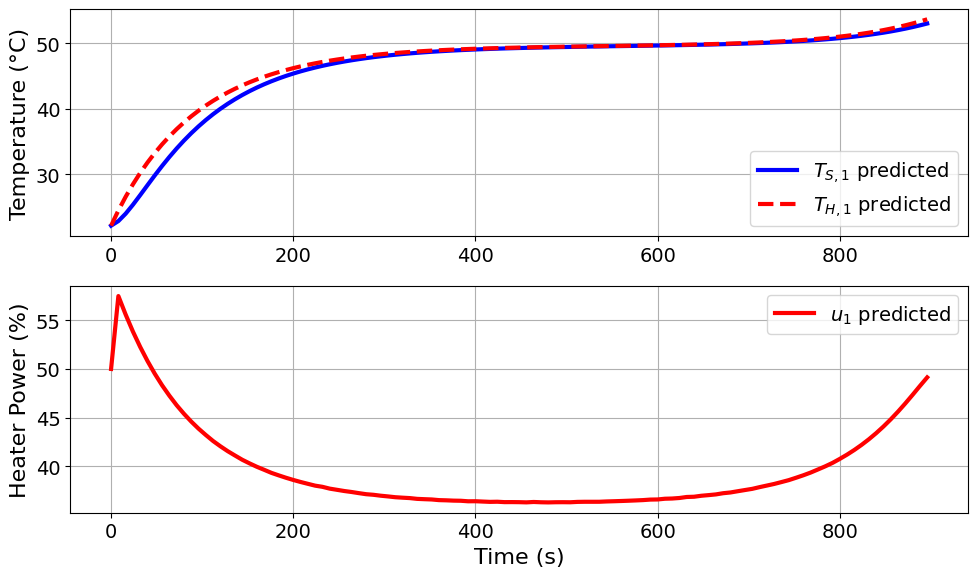

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [7]:
aopt_pyomo_doe_results = extract_plot_results(
    None, TC_Lab_DoE_A.model.fd_scenario_blocks[0]
)

Interestingly, the A-optimal design produces an optimized experiment that differs from the initial sine-wave experiment. The optimized input has a structured heating profile, with heater power initially increasing and then gradually decreasing before rising again near the end of the experiment.

The predicted temperature trajectory remains in a relatively high temperature range for much of the experiment. This suggests that, for this example, the A-optimal criterion favors an experiment that maintains initial heating followed by a gradual cooling behavior.


Now, let us check whether the updated FIM after the A-optimal experiment is full rank.

In [8]:
FIM_new = np.asarray(TC_Lab_DoE_A.results["FIM"], dtype=float)

if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_array = D @ FIM_new @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_array = FIM_new / SCALE_CONSTANT_VALUE**2

rank = np.linalg.matrix_rank(FIM_array)
num_params = FIM_array.shape[0]

print(f"FIM rank:{rank} out of {num_params} parameters")

FIM rank:4 out of 4 parameters


The updated FIM has rank 4 out of 4, so it is full rank. This means that the prior information and the new A-optimal experiment together provide independent information about all four parameter directions.

Next, we examine the eigendecomposition of the optimized FIM after transforming it back to the original parameter convention. This lets us compare how well the different parameter directions are informed using the same units as the prior FIM.

In [9]:
FIM_A = np.asarray(TC_Lab_DoE_A.results["FIM"])

if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled_A = D @ FIM_A @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled_A = FIM_A / SCALE_CONSTANT_VALUE**2

results_summary(np.asarray(FIM_unscaled_A))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.228823718899736
A-optimality: -7.344189216604481
D-optimality: 36.12453647740226
E-optimality: 7.3571744564960255
Modified E-optimality: 2.5874369341369157

FIM:
 [[ 7.17766342e+09  1.00811756e+08 -2.18902209e+08 -1.11895723e+06]
 [ 1.00811756e+08  8.99331580e+08  1.51888644e+08  2.52803162e+06]
 [-2.18902209e+08  1.51888644e+08  5.69002719e+07  1.33819141e+06]
 [-1.11895723e+06  2.52803162e+06  1.33819141e+06  8.80260677e+09]]

eigenvalues:
 [7.18585554e+09 2.27601152e+07 9.25277812e+08 8.80260858e+09]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9994    0.0326    0.0098   -0.0007
Ub         0.0153   -0.1743   -0.9846    0.0003
inv_CpH   -0.0304    0.9842   -0.1747    0.0002
inv_CpS    0.0007   -0.0001    0.0003    1.0000


Let us identify the parameter with minimum information

In [10]:
parameter_names = np.array(["Ua", "Ub", "inv_CpH", "inv_CpS"])


def print_min_eigenvalue_direction(FIM, label):
    eigvals, eigvecs = np.linalg.eigh(np.asarray(FIM, dtype=float))
    idx_min = np.argmin(eigvals)

    lambda_min = eigvals[idx_min]
    eigvec_min = eigvecs[:, idx_min]
    dominant_parameter = parameter_names[np.argmax(np.abs(eigvec_min))]

    print(f"=== Minimum-eigenvalue direction for {label} ===")
    print(f"lambda_min = {lambda_min:.3e}")
    print("\nEigenvector associated with lambda_min:")
    for name, value in zip(parameter_names, eigvec_min):
        print(f"  {name}: {value:.4f}")
    print(f"\nDominant parameter component: {dominant_parameter}")


print_min_eigenvalue_direction(FIM_A, "A-optimal scaled FIM")

=== Minimum-eigenvalue direction for A-optimal scaled FIM ===
lambda_min = 4.260e+04

Eigenvector associated with lambda_min:
  Ua: -0.0000
  Ub: 0.0000
  inv_CpH: -0.0028
  inv_CpS: 1.0000

Dominant parameter component: inv_CpS


The eigendecomposition shows that the least-informed parameter direction is dominated by $\mathrm{inv}\_C_p^S$, as indicated by the fourth eigenvector. 

These results suggest that the prior information and the new A-optimal experiment together provide enough independent information to estimate all four model parameters. However, the smallest eigenvalue is still associated primarily with $\mathrm{inv}\_C_p^S$, so additional experiments that increase information in the direction of the smallest value could further improve conditioning. This leads us to the E and ME-optimalty criteria.

The A-optimal experiment makes the updated FIM full rank, but the eigendecomposition shows that the information is still unevenly distributed across parameter directions. This motivates eigenvalue-based criteria that focus directly on the weakest-informed direction.

E-optimality and modified E-optimality both depend directly on the eigenvalues of $\mathbf{M}(u) + \mathbf{M}_0$:


E-optimality and modified E-optimality are different because they depend directly on the eigenvalues of $\mathbf{M}(u) + \mathbf{M}_0$:

$$
\text{E-optimality:} \qquad
\max_u \ \lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0),
$$

$$
\text{Modified E-optimality:} \qquad
\min_u \
\frac{\lambda_{\max}(\mathbf{M}(u) + \mathbf{M}_0)}
{\lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0)}.
$$
E-optimality maximizes the smallest eigenvalue, so it directly targets the weakest-informed parameter direction. Modified E-optimality instead reduces the spread between the largest and smallest eigenvalues, which is related to improving the conditioning of the FIM. We will put a pin in modified E-optimality for now and focus first on E-optimality.


## E-Optimality using GreyBox Formulation

Eigenvalue-based objectives are not as convenient to express using standard algebraic constraints. Pyomo.DoE therefore uses a GreyBox formulation for objectives such as E-optimality and modified E-optimality.

In this formulation, the Pyomo model computes the total Fisher information matrix,

$$
\mathbf{M}(u) + \mathbf{M}_0,
$$

and the GreyBox block evaluates the scalar design criterion externally as

$$
\psi = \psi\left(\mathbf{M}(u) + \mathbf{M}_0\right).
$$

For E-optimality, the GreyBox block evaluates

$$
\psi\left(\mathbf{M}(u) + \mathbf{M}_0\right)
=
\lambda_{\min}\left(\mathbf{M}(u) + \mathbf{M}_0\right).
$$

Thus:

- the Pyomo model computes $\mathbf{Q}(u)$ and $\mathbf{M}(u) + \mathbf{M}_0$,
- the GreyBox block takes $\mathbf{M}(u) + \mathbf{M}_0$ as input,
- the GreyBox block returns the smallest eigenvalue, $\lambda_{\min}\left(\mathbf{M}(u) + \mathbf{M}_0\right)$, as the scalar objective value.

The GreyBox callback also provides derivative information, such as

$$
\frac{\partial \psi}{\partial \mathbf{M}},
$$

and optionally second-derivative information. This allows a gradient-based optimizer such as IPOPT to solve the resulting problem efficiently.


We now formulate and solve the next experiment design problem using E-optimality with the GreyBox objective implementation. In `DesignOfExperiments`, this is specified with `objective_option="minimum_eigenvalue"` and `use_grey_box_objective=True`.

In [11]:
# Create the design of experiments object for E-optimality

TC_Lab_DoE_E = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="minimum_eigenvalue",  # E-optimality
    prior_FIM=PRIOR_FIM_SCALED,
    tee=True,
    solver=solver,
    jac_initial=init_jac,
    fim_initial=init_fim,
    # Use the GreyBox objective implementation
    use_grey_box_objective=True,
)

# Solve the E-optimal design problem
TC_Lab_DoE_E.run_doe()

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1344
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      450
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      224
                     variables with only upper bo

In [12]:
print("=== E-optimal design summary ===")


FIM_E = np.asarray(TC_Lab_DoE_E.results["FIM"])

if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled_E = D @ FIM_E @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled_E = FIM_E / SCALE_CONSTANT_VALUE**2

results_summary(np.asarray(FIM_unscaled_E))

=== E-optimal design summary ===
======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.40538933702501
A-optimality: -7.344757012894263
D-optimality: 36.41800304251813
E-optimality: 7.357207442317425
Modified E-optimality: 2.880780432807809

FIM:
 [[ 7.17860467e+09  1.00811956e+08 -2.18889626e+08  1.44656942e+03]
 [ 1.00811956e+08  8.99331580e+08  1.51888643e+08  2.51155958e+06]
 [-2.18889626e+08  1.51888643e+08  5.69001125e+07  4.33458286e+05]
 [ 1.44656942e+03  2.51155958e+06  4.33458286e+05  1.72976803e+10]]

eigenvalues:
 [7.18679572e+09 2.27618440e+07 9.25278402e+08 1.72976807e+10]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9994   -0.0326   -0.0098    0.0000
Ub        -0.0153    0.1743    0.9846    0.0002
inv_CpH    0.0304   -0.9842    0.1747    0.0000
inv_CpS    0.0000   -0.0000   -0.0002    1.0000


Let us identify the parameter about which minimum information is known

In [13]:
parameter_names = np.array(["Ua", "Ub", "inv_CpH", "inv_CpS"])


def print_min_eigenvalue_direction(FIM, label):
    eigvals, eigvecs = np.linalg.eigh(np.asarray(FIM, dtype=float))
    idx_min = np.argmin(eigvals)

    lambda_min = eigvals[idx_min]
    eigvec_min = eigvecs[:, idx_min]
    dominant_parameter = parameter_names[np.argmax(np.abs(eigvec_min))]

    print(f"=== Minimum-eigenvalue direction for {label} ===")
    print(f"lambda_min = {lambda_min:.3e}")
    print("\nEigenvector associated with lambda_min:")
    for name, value in zip(parameter_names, eigvec_min):
        print(f"  {name}: {value:.4f}")
    print(f"\nDominant parameter component: {dominant_parameter}")


print_min_eigenvalue_direction(FIM_E, "E-optimal scaled FIM")

=== Minimum-eigenvalue direction for E-optimal scaled FIM ===
lambda_min = 8.372e+04

Eigenvector associated with lambda_min:
  Ua: 0.0000
  Ub: -0.0000
  inv_CpH: -0.0000
  inv_CpS: 1.0000

Dominant parameter component: inv_CpS


The E-optimal design is evaluated using the scaled FIM inside `DesignOfExperiments`. For the scaled FIM, the minimum eigenvalue is approximately

$$
\lambda_{\min} \approx 8.37 \times 10^4,
$$

and the eigenvector associated with this minimum eigenvalue is dominated by $\mathrm{inv}\_C_p^S$. This indicates that, in the scaled optimization coordinates, E-optimality targets the sensor heat-capacity direction.

After transforming the optimized FIM back to the original parameter convention, the smallest eigenvalue of the unscaled FIM is approximately

$$
\lambda_{\min} \approx 2.28 \times 10^7.
$$

We use the scaled FIM to interpret what the optimizer targeted, and the unscaled FIM to report summaries and compare metrics across designs.

We next visualize the optimized experiment.

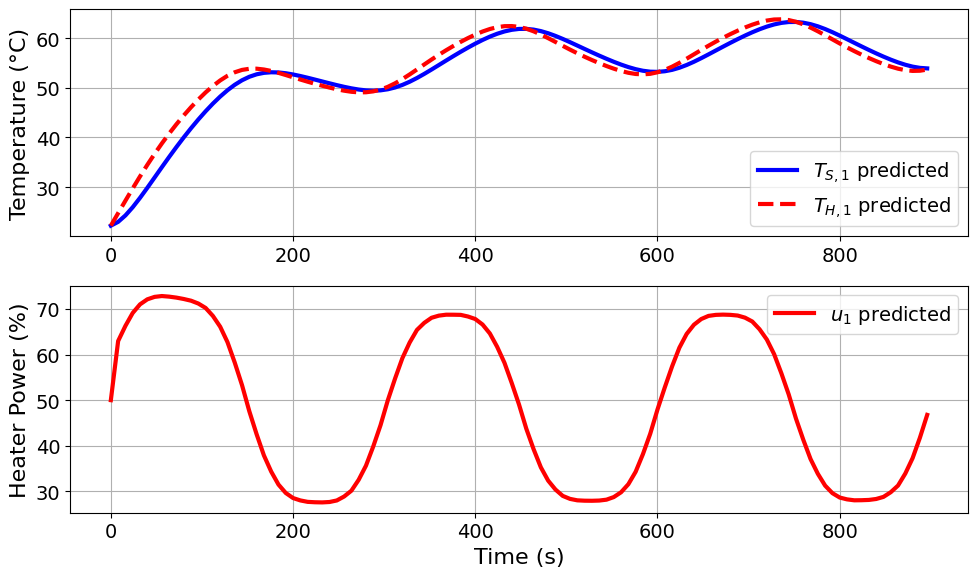

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [14]:
Eopt_pyomo_doe_results = extract_plot_results(
    None, TC_Lab_DoE_E.model.fd_scenario_blocks[0]
)

The E-optimal solution produces a repeated heating and cooling structure. The input increases the heater power early in the experiment, then alternates between lower and higher heater power over the remaining time horizon. This input profile is selected to improve information in the weakest-informed direction of the FIM.

## Sensitivity Analysis

The E-optimal design targets the smallest eigenvalue of the scaled FIM used inside `DesignOfExperiments`. This minimum eigenvalue corresponds to the weakest-informed direction in the scaled optimization coordinates. The eigenvector associated with this minimum eigenvalue is dominated by $\mathrm{inv}\_C_p^S$, indicating that the E-optimal objective is primarily targeting the sensor heat-capacity direction.

We therefore perform a local sensitivity analysis around the nominal value

$$
C_p^S = 0.22\ \mathrm{J}/^\circ\mathrm{C}.
$$

This lets us check whether the E-optimal input profile and predicted temperature trajectory are robust to small changes in the parameter direction emphasized by the scaled optimization problem.

In [15]:
import numpy as np


CpS_values = np.array([0.2, 0.21, 0.22, 0.23, 0.24])
e_opt = np.zeros((len(CpS_values)))
u_solutions = np.zeros((len(CpS_values), len(tc_data.time)))
Ts_solutions = np.zeros((len(CpS_values), len(tc_data.time)))

for i, v in enumerate(CpS_values):

    print("\n********************\nCpS = ", v, " J/°C")

    theta_values_new = theta_values.copy()
    theta_values_new["inv_CpS"] = 1 / v

    # Create experiment object for design of experiments
    doe_experiment = TC_Lab_experiment(
        data=tc_data,
        theta_initial=theta_values_new,
        number_of_states=number_tclab_states,
    )

    FIM_new = TC_Lab_DoE.compute_FIM(method="sequential")

    # Create a new DoE object
    TC_Lab_DoE = DesignOfExperiments(
        experiment=doe_experiment,
        step=1e-2,
        scale_constant_value=SCALE_CONSTANT_VALUE,
        scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
        objective_option="minimum_eigenvalue",  # We specify a type of objective, A-opt = "trace"
        prior_FIM=PRIOR_FIM_SCALED,  # We use the prior information from the original experiment
        tee=False,
        solver=solver,
        jac_initial=init_jac,
        fim_initial=init_fim,
        # Use the GreyBox objective implementation
        use_grey_box_objective=True,
    )

    TC_Lab_DoE.run_doe()

    pyomo_results = extract_results(TC_Lab_DoE.model.fd_scenario_blocks[0])

    FIM_i = np.asarray(TC_Lab_DoE.results["FIM"], dtype=float)

    if SCALE_BY_NOMINAL_PARAM:
        D = np.diag(theta_ref)
        FIM_array = D @ FIM_i @ D / SCALE_CONSTANT_VALUE**2
    else:
        FIM_array = FIM_i / SCALE_CONSTANT_VALUE**2

    results_summary(np.asarray(FIM_array))

    e_opt[i] = np.linalg.eigvalsh(FIM_array)[0]

    u_solutions[i, :] = pyomo_results.u1
    Ts_solutions[i, :] = pyomo_results.TS1_data

    print("********************\n")


********************
CpS =  0.2  J/°C
Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1344
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      450
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      224
          

Now let's visualize how the *E-optimality objective* changes as a function of $C_p^S$.

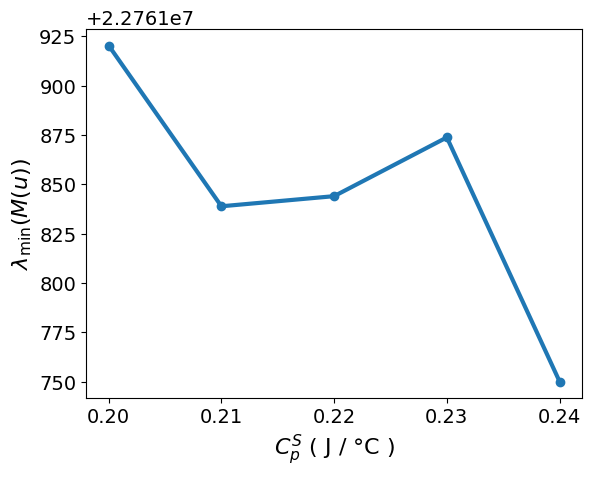

In [16]:
import matplotlib.pyplot as plt

plt.plot(CpS_values, e_opt, marker="o")
plt.xlabel("$C_p^S$ ( J / °C )")
plt.ylabel(r"$\lambda_{\min}(M(u))$")
plt.show()

The E-optimality objective, $\lambda_{\min}(\mathbf{M}(u) + M_0)$, remains on the order of $10^7$ over the tested local range of $C_p^S$. The smallest eigenvalue is largest near $C_p^S = 0.20$ and $0.22$ J/°C, decreases noticeably near $C_p^S = 0.21$ J/°C, and then changes only modestly from $C_p^S = 0.22$ to $0.24$ J/°C.

This shows that the amount of information in the weakest-informed direction is somewhat sensitive to the assumed value of $C_p^S$, but remains in the same order of magnitude across the tested range. Next, we check whether the optimized input profile and predicted temperature trajectory also change across this local range.

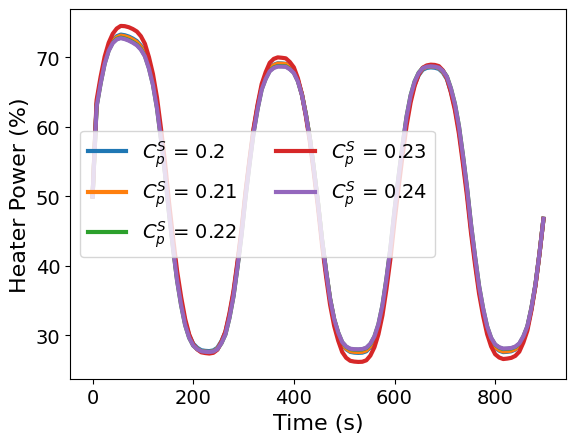

In [17]:
for i, v in enumerate(CpS_values):
    plt.plot(tc_data.time, u_solutions[i, :], label=f"$C_p^S$ = {v}")
plt.legend(ncol=2, loc="best")
plt.xlabel("Time (s)")
plt.ylabel("Heater Power (%)")
plt.show()

The corresponding optimal heater profiles are nearly identical across the tested values of $C_p^S$. All solutions retain the same repeated heating and cooling structure, with only small differences in the timing and magnitude of the heater input. Over this local range, changing $C_p^S$ has little effect on the E-optimal input design.

This suggests that the E-optimal design is locally robust to perturbations in the assumed sensor heat capacity.

Next, we examine the corresponding sensor-temperature profiles.

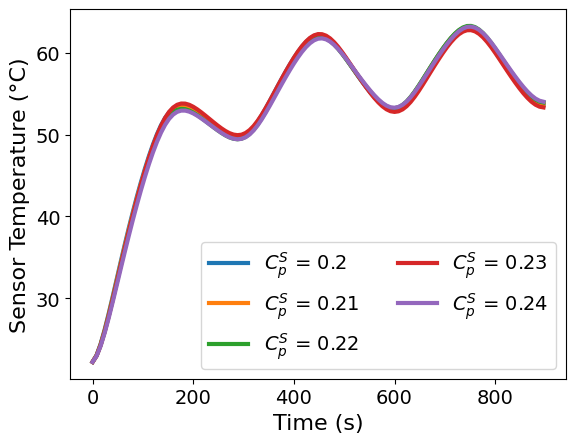

In [18]:
for i, v in enumerate(CpS_values):
    plt.plot(tc_data.time, Ts_solutions[i, :], label=f"$C_p^S$ = {v}")
plt.legend(ncol=2, loc="best")
plt.xlabel("Time (s)")
plt.ylabel("Sensor Temperature (°C)")
plt.show()

The predicted sensor-temperature trajectories are also very similar across the tested values of $C_p^S$. The profiles follow the same heating and cooling pattern, with only small differences in peak temperature and cooling behavior.

Together, the heater profiles and temperature trajectories suggest that the E-optimal design is locally robust to small changes in $C_p^S$ around the nominal value, even though the value of the E-optimality objective itself changes across the tested range.

The local sensitivity analysis shows that the E-optimal design structure is fairly stable near the nominal value of $C_p^S$. The heater profiles and predicted temperature trajectories remain qualitatively similar across the tested range, even though the value of the E-optimality objective changes.

This tells us that the E-optimal design is robust, at least locally, to perturbations in the parameter direction emphasized by the scaled optimization problem. However, to understand the overall quality of the information matrix, we should look at the entire eigenvalue spectrum, not only the smallest eigenvalue.

For the E-optimal design, the smallest eigenvalue of the unscaled optimized FIM is approximately

$$
\lambda_{\min} \approx 2.28 \times 10^7,
$$

while the largest eigenvalue is approximately

$$
\lambda_{\max} \approx 1.73 \times 10^{10}.
$$

Therefore, the ratio between the largest and smallest eigenvalues is approximately

$$
\frac{\lambda_{\max}}{\lambda_{\min}}
\approx
\frac{1.73 \times 10^{10}}{2.28 \times 10^7}
\approx 7.60 \times 10^2.
$$

This ratio is a measure of conditioning. A smaller ratio means the FIM has a more balanced distribution of information across parameter directions. A large ratio means that some parameter directions are much better informed than others.

Although E-optimality targets the minimum eigenvalue, the optimized FIM can still be unevenly conditioned. This motivates modified E-optimality, which seeks to reduce the ratio between the largest and smallest eigenvalues, encouraging a more balanced information matrix.

## Modified E (ME)-Optimality

We now turn to modified E-optimality, which uses the ratio between the largest and smallest eigenvalues of the updated FIM:

$$
\frac{\lambda_{\max}(\mathbf{M}(u) + \mathbf{M}_0)}
{\lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0)}.
$$

ME-optimality minimizes this ratio:

$$
\min_u
\frac{\lambda_{\max}(\mathbf{M}(u) + \mathbf{M}_0)}
{\lambda_{\min}(\mathbf{M}(u) + \mathbf{M}_0)}.
$$

A smaller ratio corresponds to a better-conditioned information matrix. Next, we solve the ME-optimal design problem.

In [19]:
# Create the design of experiments object
TC_Lab_DoE_ME = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="condition_number",  # ME-optimality
    prior_FIM=PRIOR_FIM_SCALED,
    tee=True,
    solver=solver,
    jac_initial=init_jac,
    fim_initial=init_fim,
    # Use the GreyBox objective implementation
    use_grey_box_objective=True,
)


# Solve
TC_Lab_DoE_ME.run_doe()

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1344
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      450
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      224
                     variables with only upper bo

Let us analyze the FIM

In [20]:
print("=== ME-optimal design summary ===")


FIM_ME = np.asarray(TC_Lab_DoE_ME.results["FIM"])

if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled_ME = D @ FIM_ME @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled_ME = FIM_ME / SCALE_CONSTANT_VALUE**2

results_summary(np.asarray(FIM_unscaled_ME))

=== ME-optimal design summary ===
======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.55380290159041
A-optimality: -7.547693027127779
D-optimality: 36.831949918692615
E-optimality: 7.567377611123783
Modified E-optimality: 2.87423715153416

FIM:
 [[ 7.17766412e+09  1.00811666e+08 -2.18834269e+08 -2.41672729e+06]
 [ 1.00811666e+08  8.99331624e+08  1.51862897e+08  2.22350858e+06]
 [-2.18834269e+08  1.51862897e+08  7.22554273e+07  1.42641815e+08]
 [-2.41672729e+06  2.22350858e+06  1.42641815e+08  2.76441445e+10]]

eigenvalues:
 [7.18586488e+09 2.76448834e+10 3.69298557e+07 9.25717552e+08]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9994   -0.0002   -0.0326   -0.0097
Ub         0.0153    0.0001    0.1770    0.9841
inv_CpH   -0.0304    0.0052   -0.9837    0.1774
inv_CpS    0.0003    1.0000    0.0051   -0.0010


The ME-optimal design targets the conditioning of the FIM by reducing the spread between the largest and smallest eigenvalues. For this design, the smallest eigenvalue of the unscaled optimized FIM is approximately

$$
\lambda_{\min} \approx 3.69 \times 10^7,
$$

while the largest eigenvalue is approximately

$$
\lambda_{\max} \approx 2.76 \times 10^{10}.
$$

This gives a largest-to-smallest eigenvalue ratio of approximately

$$
\frac{\lambda_{\max}}{\lambda_{\min}}
\approx
\frac{2.76 \times 10^{10}}{3.69 \times 10^7}
\approx
7.49 \times 10^2.
$$

Let us identify parameter with the minimum information

In [21]:
parameter_names = np.array(["Ua", "Ub", "inv_CpH", "inv_CpS"])


def print_min_eigenvalue_direction(FIM, label):
    eigvals, eigvecs = np.linalg.eigh(np.asarray(FIM, dtype=float))
    idx_min = np.argmin(eigvals)

    lambda_min = eigvals[idx_min]
    eigvec_min = eigvecs[:, idx_min]
    dominant_parameter = parameter_names[np.argmax(np.abs(eigvec_min))]

    print(f"=== Minimum-eigenvalue direction for {label} ===")
    print(f"lambda_min = {lambda_min:.3e}")
    print("\nEigenvector associated with lambda_min:")
    for name, value in zip(parameter_names, eigvec_min):
        print(f"  {name}: {value:.4f}")
    print(f"\nDominant parameter component: {dominant_parameter}")


print_min_eigenvalue_direction(FIM_ME, "ME-optimal scaled FIM")

=== Minimum-eigenvalue direction for ME-optimal scaled FIM ===
lambda_min = 1.173e+05

Eigenvector associated with lambda_min:
  Ua: -0.0054
  Ub: 0.0082
  inv_CpH: -0.6613
  inv_CpS: 0.7500

Dominant parameter component: inv_CpS


Compared with the E-optimal design, modified E-optimality changes the minimum-eigenvalue direction in the scaled FIM. The direction is still largest in $\mathrm{inv}\_C_p^S$.

ME-optimality targets the ratio between the largest and smallest eigenvalues, so its goal is to improve the balance of information across parameter directions. In the final unscaled FIM comparison, the ME-optimal design gives a slightly smaller condition number ($748.58$) than the E-optimal design ($759.94$).

Let us visualize the resulting optimal control trajectory.

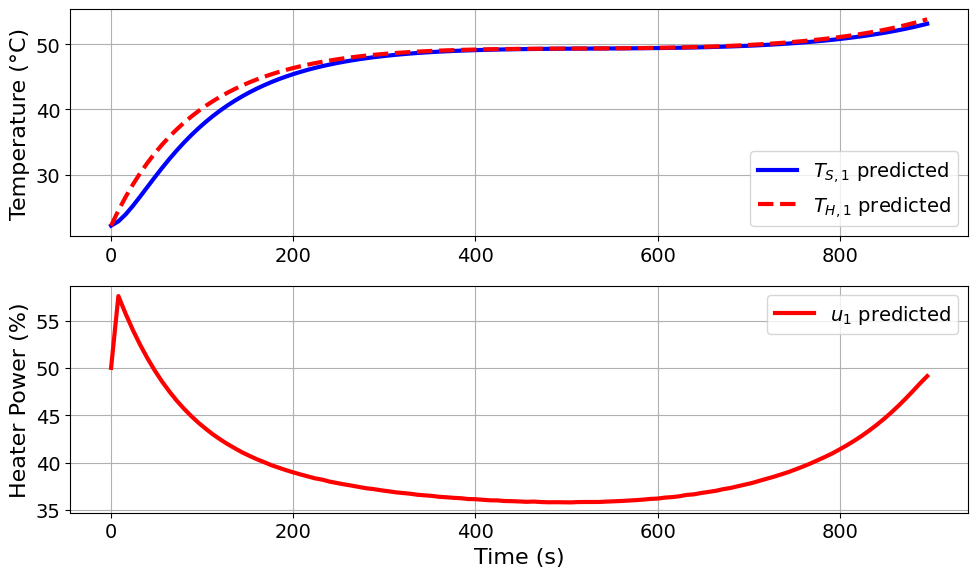

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.24 Joules/°C
 


In [22]:
MEopt_pyomo_doe_results = extract_plot_results(
    None, TC_Lab_DoE_ME.model.fd_scenario_blocks[0]
)

The ME-optimal design produces a smoother heater-input profile than the E-optimal design. Instead of repeatedly switching between high and low heater power, the input rises briefly, decreases over the middle of the experiment, and then increases again near the end.

This behavior reflects the goal of ME-optimality: rather than focusing only on the weakest-informed direction, it seeks to balance information across parameter directions by reducing the spread between the largest and smallest eigenvalues of the FIM. The resulting temperature trajectories are correspondingly smooth, with both the heater and sensor temperatures increasing gradually over the experiment.

The modified E-optimal input profile is noticeably different from the E-optimal design. Instead of using several shorter heating and cooling cycles, the ME-optimal design uses a smoother profile: it decreases the heater input early, increases it through the middle of the experiment, decreases it again, and then raises the heater input near the end.

This behavior is consistent with the objective: ME-optimality targets the conditioning of the FIM by reducing the spread between the largest and smallest eigenvalues. The resulting trajectory explores a broader heating and cooling response, which helps balance information across parameter directions.

## Optimize Next Experiment (D-Optimality)

We now return to D-optimality which is another option available within `Pyomo.DoE` by setting `objective_option="determinant"`. This criterion seeks an experiment that increases the determinant of the Fisher information matrix, which corresponds to reducing the overall parameter uncertainty volume.

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1344
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      450
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      224
                     variables with only upper bo

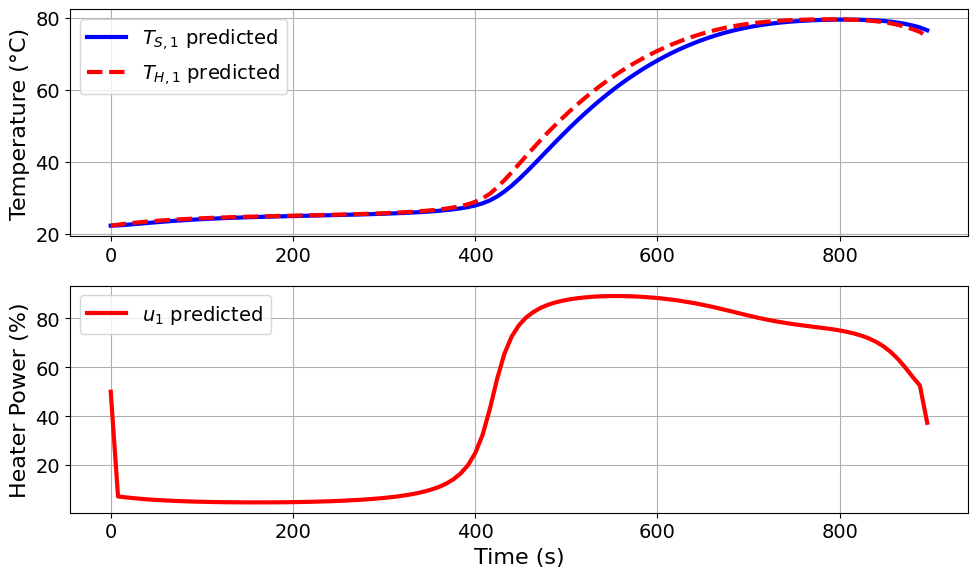

Model parameters:
Ua = 0.0421 Watts/°C
Ub = 0.012 Watts/°C
CpH = 5.9717 Joules/°C
CpS = 0.22 Joules/°C
 


In [23]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states
)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=PRIOR_FIM_SCALED,  # Use prior information from the existing experiment.
    tee=True,
    solver=solver,
    jac_initial=init_jac,
    fim_initial=init_fim,
    # Use the GreyBox objective implementation
    use_grey_box_objective=True,
)

TC_Lab_DoE_D.run_doe()

dopt_pyomo_doe_results = extract_plot_results(
    None, TC_Lab_DoE_D.model.fd_scenario_blocks[0]
)

The D-optimal design produces a more aggressive heating profile than the ME-optimal design. The heater input rises close to its upper bound early in the experiment, then drops sharply near the middle of the time horizon and remains low for much of the remaining experiment.

D-optimality seeks to increase the overall information volume, rather than focusing only on the weakest-informed direction or on balancing the eigenvalue spread. The resulting temperature trajectory covers a wide range of temperatures, which helps excite the model dynamics and increase the determinant of the FIM.

Let us analyze the FIM

In [24]:
# Unscaling FIM and analyzing the eigendecomposition
FIM_D = np.asarray(TC_Lab_DoE_D.results["FIM"])

if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled_D = D @ FIM_D @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled_D = FIM_D / SCALE_CONSTANT_VALUE**2

results_summary(np.asarray(FIM_unscaled_D))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 11.493023374039673
A-optimality: -8.346651598171551
D-optimality: 38.79029702065936
E-optimality: 8.483582161268167
Modified E-optimality: 2.9975144272879466

FIM:
 [[ 7.18985482e+09  9.70637840e+07 -1.60255091e+08  6.78823643e+07]
 [ 9.70637840e+07  9.00484027e+08  1.33848142e+08 -1.56669621e+07]
 [-1.60255091e+08  1.33848142e+08  3.39563394e+08  2.29483774e+08]
 [ 6.78823643e+07 -1.56669621e+07  2.29483774e+08  3.02758479e+11]]

eigenvalues:
 [3.02758670e+11 7.19499026e+09 3.04496399e+08 9.30225115e+08]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.0002    0.9996    0.0258    0.0094
Ub        -0.0001    0.0149   -0.2231   -0.9747
inv_CpH    0.0008   -0.0231    0.9745   -0.2234
inv_CpS    1.0000   -0.0002   -0.0008    0.0001




Now that we have solved the A-, E-, ME-, and D-optimal design problems, we can compare the resulting Fisher information matrices using the same set of summary metrics. This comparison helps us see the tradeoffs between criteria: each design optimizes one objective, but may improve or degrade the others.

To compare the four optimized designs, we evaluate the same FIM summary metrics for each design. The table reports log-scaled values so the metrics can be compared on a similar numerical scale.

For D-, pseudo A-, and E-style information metrics, larger values indicate more information according to that criterion. For true A-optimality, which is based on $\mathrm{trace}(M^{-1})$, lower values indicate lower average parameter uncertainty. For the condition-number metric, lower is better because the largest and smallest eigenvalues are closer together, corresponding to a better-conditioned FIM.

## FIM Comparison for All Optimalities

To compare the four optimized designs, we evaluate the same FIM summary metrics for each design. The table reports log-scaled values so the metrics can be compared on a similar numerical scale.

For the A-, D-, and E-style metrics, larger values indicate more information according to that criterion. For the condition-number metric, lower is better because it means the largest and smallest eigenvalues are closer together, corresponding to a better-conditioned FIM.

In [ ]:
def fim_condition_metrics(FIM):
    eigvals = np.linalg.eigvalsh(np.asarray(FIM, dtype=float))
    lambda_min = np.min(eigvals)
    lambda_max = np.max(eigvals)
    condition_number = lambda_max / lambda_min

    return {
        "λ_min": lambda_min,
        "λ_max": lambda_max,
        "κ(M) = λ_max / λ_min": condition_number,
    }


condition_df = pd.DataFrame(
    {
        "D-opt design": fim_condition_metrics(FIM_unscaled_D),
        "A-opt design": fim_condition_metrics(FIM_unscaled_A),
        "E-opt design": fim_condition_metrics(FIM_unscaled_E),
        "ME-opt design": fim_condition_metrics(FIM_unscaled_ME),
    }
).T

condition_df = condition_df.round(
    {
        "λ_min": 2,
        "λ_max": 2,
        "κ(M) = λ_max / λ_min": 2,
    }
)

print("=== FIM conditioning comparison ===")
display(condition_df)

=== FIM conditioning comparison ===


,λ_min,λ_max,κ(M) = λ_max / λ_min
D-opt design,3.044964e+08,3.027587e+11,994.29
A-opt design,2.276012e+07,8.802609e+09,386.76
E-opt design,2.276184e+07,1.729768e+10,759.94
ME-opt design,3.692986e+07,2.764488e+10,748.58


The ME-optimal design gives the smallest condition number among the four designs in this run, but the improvement relative to E-optimality is modest (1.5\%): the condition number decreases from about $7.60 \times 10^2$ for the E-optimal design to about $7.49 \times 10^2$ for the ME-optimal design.

This comparison shows that ME-optimality targets the eigenvalue spread, but in this example the final unscaled FIM conditioning is similar for the E- and ME-optimal designs. The designs still differ in their optimized input profiles and in the tradeoffs they make among the other FIM-based metrics.